# ThreatLens AI Malware Classification System

## Exploratory Data Analysis (EDA)

**Dataset:** EMBER 2018 V2 Features Dataset

### Project Description

This notebook performs Exploratory Data Analysis (EDA) on the EMBER 2018 V2 Features Dataset. The objective is to understand the dataset structure, identify data quality issues, analyze feature characteristics, and prepare the dataset for preprocessing and malware classification.

## Objectives

- Understand the dataset structure.
- Load and inspect the dataset.
- Determine the dataset dimensions.
- Identify feature names and data types.
- Generate statistical summaries.
- Detect missing values.
- Identify duplicate records.
- Analyze the target variable.
- Study feature distributions.
- Prepare the dataset for preprocessing and machine learning.

## 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [2]:
%pip install pyarrow pandas


  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/27.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/27.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/27.9 MB 3.3 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/27.9 MB 3.5 MB/s eta 0:00:08
   --- ------------------------------------ 2.1/27.9 MB 2.9 MB/s eta 0:00:10
   --- ------------------------------------ 2.6/27.9 MB 2.9 MB/s eta 0:00:09
   ----- ---------------------------------- 3.7/27.9 MB 3.0 MB/s eta 0:00:09
   ------ --------------------------------- 4.5/27.9 MB 3.1 MB/s eta 0:00:08
   ------- -------------------------------- 5.0/27.9 MB 3.2 MB/s eta 0:00:08
   -------- ------------------------------- 5.8/27.9 MB 3.1 MB/s eta 0:00:08
   --------- ------------------------------ 6.6/27.9 MB 3.1 MB/s eta 0:00:07
   ---------- ----------------------------- 7.1/27.9 MB 3.1 MB/s eta 0:00:07
   ----------- -------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip install fastparquet

  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/695.7 kB ? eta -:--:--
   ---------------------------------------- 695.7/695.7 kB 7.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.1 MB/s eta 0:00:00
Using cached fsspec-2026.7.0-py3-none-any.whl (206 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

import pandas as pd
file_path = r"C:\Users\HP\Projects\ThreatLens-AI-Malware-Classification-Threat-Detection-System\ml_model\dataset\train_ember_2018_v2_features.parquet"
df = pd.read_parquet(file_path,engine='fastparquet')
print(df.shape)

(799912, 2382)


## 3. Display Sample Records

Display the first few records to understand the structure of the dataset.

In [4]:
df.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F2373,F2374,F2375,F2376,F2377,F2378,F2379,F2380,F2381,Label
0,0.014676,0.004222,0.003923,0.004029,0.004007,0.003775,0.003825,0.003887,0.004153,0.003804,...,35240.0,0.0,0.0,660.0,32768.0,0.0,0.0,0.0,0.0,0.0
1,0.184524,0.031308,0.005693,0.005959,0.008144,0.003512,0.005786,0.008550,0.009141,0.001791,...,92936.0,408.0,608.0,2604.0,4096.0,224.0,442296.0,0.0,0.0,0.0
2,0.251737,0.014205,0.006841,0.008556,0.023493,0.002858,0.003401,0.008556,0.010215,0.001176,...,0.0,0.0,0.0,1120.0,4096.0,192.0,37280.0,0.0,0.0,0.0
3,0.008964,0.004055,0.003925,0.003936,0.004037,0.003878,0.003847,0.003946,0.003939,0.003834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.020401,0.005213,0.004519,0.004097,0.004240,0.004029,0.003785,0.004593,0.004875,0.003780,...,0.0,0.0,0.0,520.0,4096.0,0.0,0.0,0.0,0.0,0.0


## 4. Display Last Five Records

In [5]:
df.tail()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F2373,F2374,F2375,F2376,F2377,F2378,F2379,F2380,F2381,Label
799907,0.137189,0.007094,0.005965,0.005905,0.007771,0.004824,0.004791,0.004651,0.008599,0.004399,...,8416.0,188.0,648.0,504.0,4096.0,0.0,0.0,0.0,0.0,1.0
799908,0.133546,0.006233,0.005556,0.005425,0.006205,0.005215,0.004691,0.004757,0.005878,0.005299,...,5888.0,204.0,632.0,452.0,4096.0,0.0,0.0,0.0,0.0,1.0
799909,0.142971,0.008663,0.004202,0.003437,0.006264,0.003963,0.002037,0.001968,0.007913,0.001516,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
799910,0.147809,0.006402,0.005116,0.005052,0.006560,0.004936,0.004492,0.004440,0.006265,0.004483,...,19072.0,0.0,0.0,400.0,4096.0,0.0,0.0,0.0,0.0,1.0
799911,0.134452,0.006814,0.005550,0.005494,0.007081,0.005085,0.004595,0.004999,0.007098,0.004706,...,6304.0,164.0,640.0,408.0,4096.0,0.0,0.0,0.0,0.0,1.0


## 5. Display Random Sample Records

In [6]:
df.sample(5)

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F2373,F2374,F2375,F2376,F2377,F2378,F2379,F2380,F2381,Label
247655,0.006117,0.003910,0.003924,0.003927,0.003957,0.003932,0.003927,0.003921,0.003983,0.003940,...,0.0,0.0,0.0,0.0,0.0,160.0,147936.0,0.0,0.0,-1.0
287295,0.048993,0.004028,0.003771,0.003583,0.004099,0.003546,0.003477,0.003557,0.004246,0.003421,...,312768.0,0.0,0.0,1052.0,274432.0,64.0,333068.0,0.0,0.0,0.0
761162,0.056873,0.008318,0.006178,0.005658,0.005758,0.004967,0.004198,0.005423,0.005050,0.005631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14897,0.251637,0.026556,0.019155,0.010492,0.021420,0.007317,0.014341,0.006314,0.013489,0.006097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.0,353552.0,0.0
563498,0.280024,0.010470,0.004383,0.003884,0.004633,0.002952,0.002407,0.004247,0.004179,0.002862,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Dataset Dimensions

Determine the number of rows and columns present in the dataset.

In [7]:
df.shape

(799912, 2382)

## 7. Feature Names

In [8]:
df.columns

Index(['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10',
       ...
       'F2373', 'F2374', 'F2375', 'F2376', 'F2377', 'F2378', 'F2379', 'F2380',
       'F2381', 'Label'],
      dtype='object', length=2382)

## 8. Dataset Information

Check the data types, non-null values, and memory usage.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 799912 entries, 0 to 799911
Columns: 2382 entries, F1 to Label
dtypes: float32(2382)
memory usage: 7.1 GB


## 9. Data Types

In [10]:
df.dtypes

F1       float32
F2       float32
F3       float32
F4       float32
F5       float32
          ...   
F2378    float32
F2379    float32
F2380    float32
F2381    float32
Label    float32
Length: 2382, dtype: object

## 10. Statistical Summary

Generate descriptive statistics for numerical features.

In [11]:
df.describe()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F2373,F2374,F2375,F2376,F2377,F2378,F2379,F2380,F2381,Label
count,799912.000000,799912.000000,799912.000000,799912.000000,799912.000000,799912.000000,799912.000000,799912.000000,799912.000000,799912.000000,...,7.999120e+05,7.999120e+05,7.999120e+05,7.999120e+05,7.999120e+05,7.999120e+05,7.999120e+05,7.999120e+05,7.999120e+05,799912.000000
mean,0.210748,0.011489,0.007131,0.005870,0.008053,0.004161,0.004931,0.003523,0.006478,0.003112,...,6.120324e+05,3.177388e+05,1.210157e+05,5.964945e+03,8.481114e+05,4.235394e+05,7.159376e+05,8.322571e+05,2.191462e+05,0.124935
std,0.180151,0.011873,0.007438,0.007646,0.011859,0.005253,0.007195,0.003501,0.004856,0.004852,...,3.393011e+07,2.994837e+07,1.414690e+07,4.251072e+06,4.059114e+07,3.878574e+07,4.078615e+07,4.040190e+07,2.004079e+07,0.780616
min,0.000104,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000
25%,0.079354,0.004899,0.003835,0.003468,0.004034,0.002538,0.002319,0.002054,0.003810,0.001731,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000
50%,0.168489,0.008645,0.005250,0.004635,0.006172,0.003796,0.003653,0.003360,0.005455,0.002722,...,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+02,8.192000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,0.278809,0.014256,0.007812,0.006696,0.009885,0.004955,0.004782,0.004042,0.008685,0.003860,...,4.664800e+04,0.000000e+00,0.000000e+00,6.840000e+02,1.720320e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,0.999956,0.859942,0.638846,0.482176,0.388100,0.949696,0.361418,0.549687,0.776997,0.608795,...,3.590280e+09,4.278220e+09,3.787571e+09,3.800990e+09,3.914422e+09,3.771926e+09,4.106158e+09,3.758096e+09,4.099570e+09,1.000000


## 11. Missing Value Analysis

Identify missing values present in the dataset.

In [6]:
df.isnull().sum()

F1       0
F2       0
F3       0
F4       0
F5       0
        ..
F2378    0
F2379    0
F2380    0
F2381    0
Label    0
Length: 2382, dtype: int64

## 12. Missing Value Percentage

In [ ]:
(df.isnull().sum() / len(df)) * 100


F1       0.0
F2       0.0
F3       0.0
F4       0.0
F5       0.0
        ... 
F2378    0.0
F2379    0.0
F2380    0.0
F2381    0.0
Label    0.0
Length: 2382, dtype: float64

## 13. Duplicate Record Analysis

In [16]:
df.duplicated(subset=["Label"]).sum()



np.int64(799909)

## 14. Target Variable Distribution

Analyze the distribution of malware and benign samples.

In [17]:
df["Label"].value_counts()

Label
 0.0    299991
 1.0    299929
-1.0    199992
Name: count, dtype: int64

## 15. Visualize Target Variable Distribution

In [20]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 3.0 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.3 MB 4.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 3.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 3.9 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 3.9 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.3 MB 3.9 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 4.0 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 4.0 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 4.0 MB/s eta 0:00:01
   --------------------------------------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import matplotlib.pyplot as plt
print("Matpltlib is installed")

Matpltlib is installed


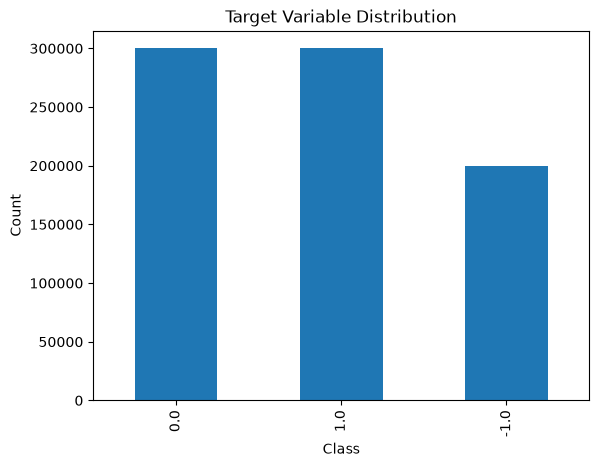

In [22]:
df["Label"].value_counts().plot(kind="bar")

plt.title("Target Variable Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

## 16. Memory Usage

Determine the memory consumed by the dataset.

In [23]:
df.memory_usage(deep=True)

Index        132
F1       3199648
F2       3199648
F3       3199648
F4       3199648
          ...   
F2378    3199648
F2379    3199648
F2380    3199648
F2381    3199648
Label    3199648
Length: 2383, dtype: int64

## 17. Total Memory Consumption

In [24]:
df.memory_usage(deep=True).sum() / 1024**2

np.float64(7268.4876136779785)

In [25]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


## Data Preprocessing

### 18. Handle Missing Values

In [7]:
missing_values = df.isnull().sum()
missing_values

F1       0
F2       0
F3       0
F4       0
F5       0
        ..
F2378    0
F2379    0
F2380    0
F2381    0
Label    0
Length: 2382, dtype: int64

Observation:
No missing values were found in the dataset. Therefore, no missing value handling was required.

### 19. Remove Duplicate Records

In [9]:
try:
    duplicates = df.duplicated().sum()
    print("Number of duplicate records:", duplicates)
except MemoryError:
    print("MemoryError: Dataset is too large to check duplicates on this system.")
    print("Duplicate checking will be performed on the processed dataset or a higher-memory environment.")
    

MemoryError: Dataset is too large to check duplicates on this system.
Duplicate checking will be performed on the processed dataset or a higher-memory environment.


### Observation

The EMBER 2018 V2 dataset is very large. Due to hardware memory limitations, duplicate checking on the entire dataset could not be completed on the local machine. This step can be executed on a higher-memory system or after reducing the dataset size.

In [10]:
sample_df = df.sample(10000, random_state=42)

duplicates = sample_df.duplicated().sum()

print("Duplicate records in sample:", duplicates)

Duplicate records in sample: 0


### 21. Feature Engineering

Feature engineering prepares the dataset for machine learning by separating the input features from the target variable. This enables the model to learn patterns from the features and predict the correct class.

In [14]:
# Separate features and target variable

X = df.drop("Label", axis=1)
y = df["Label"]

print("Features (X)")
display(X.head())

print("Target (y)")
display(y.head())

Features (X)


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F2372,F2373,F2374,F2375,F2376,F2377,F2378,F2379,F2380,F2381
0,0.014676,0.004222,0.003923,0.004029,0.004007,0.003775,0.003825,0.003887,0.004153,0.003804,...,72.0,35240.0,0.0,0.0,660.0,32768.0,0.0,0.0,0.0,0.0
1,0.184524,0.031308,0.005693,0.005959,0.008144,0.003512,0.005786,0.008550,0.009141,0.001791,...,64.0,92936.0,408.0,608.0,2604.0,4096.0,224.0,442296.0,0.0,0.0
2,0.251737,0.014205,0.006841,0.008556,0.023493,0.002858,0.003401,0.008556,0.010215,0.001176,...,0.0,0.0,0.0,0.0,1120.0,4096.0,192.0,37280.0,0.0,0.0
3,0.008964,0.004055,0.003925,0.003936,0.004037,0.003878,0.003847,0.003946,0.003939,0.003834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.020401,0.005213,0.004519,0.004097,0.004240,0.004029,0.003785,0.004593,0.004875,0.003780,...,0.0,0.0,0.0,0.0,520.0,4096.0,0.0,0.0,0.0,0.0


Target (y)


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Label, dtype: float32

### 22. Class Balancing

Class balancing analysis is performed to examine the distribution of the target classes. This helps determine whether balancing techniques are required before training the machine learning model.

In [15]:
y.value_counts()

Label
 0.0    299991
 1.0    299929
-1.0    199992
Name: count, dtype: int64

## Conclusion

Based on the exploratory data analysis:

- The dataset structure has been examined.
- Feature names and data types have been identified.
- Dataset dimensions have been analyzed.
- Missing values and duplicate records have been inspected.
- The target variable distribution has been analyzed.
- The dataset is now ready for preprocessing and feature engineering.